Merged dataset sample:
        date   fwd_1y1y   fwd_5y5y  spread_5y5y_minus_1y1y  ipca_mom  \
0 2010-01-04  12.577656  13.648011                1.070356      0.41   
1 2010-01-05  12.532078  13.655328                1.123250      0.41   
2 2010-01-06  12.471913  13.703439                1.231526      0.41   
3 2010-01-07  12.458073  13.735637                1.277564      0.41   
4 2010-01-08  12.467929  13.652784                1.184855      0.41   

   ipca_12m  ipca_3m_saar release_date_x  ibc_br_sa_level release_date_y  \
0  4.218494       3.78376     2009-12-10         91.29501     2009-12-15   
1  4.218494       3.78376     2009-12-10         91.29501     2009-12-15   
2  4.218494       3.78376     2009-12-10         91.29501     2009-12-15   
3  4.218494       3.78376     2009-12-10         91.29501     2009-12-15   
4  4.218494       3.78376     2009-12-10         91.29501     2009-12-15   

  available_date  focus_ipca_12m  focus_ipca_12m_chg_5d  \
0     2010-01-01            

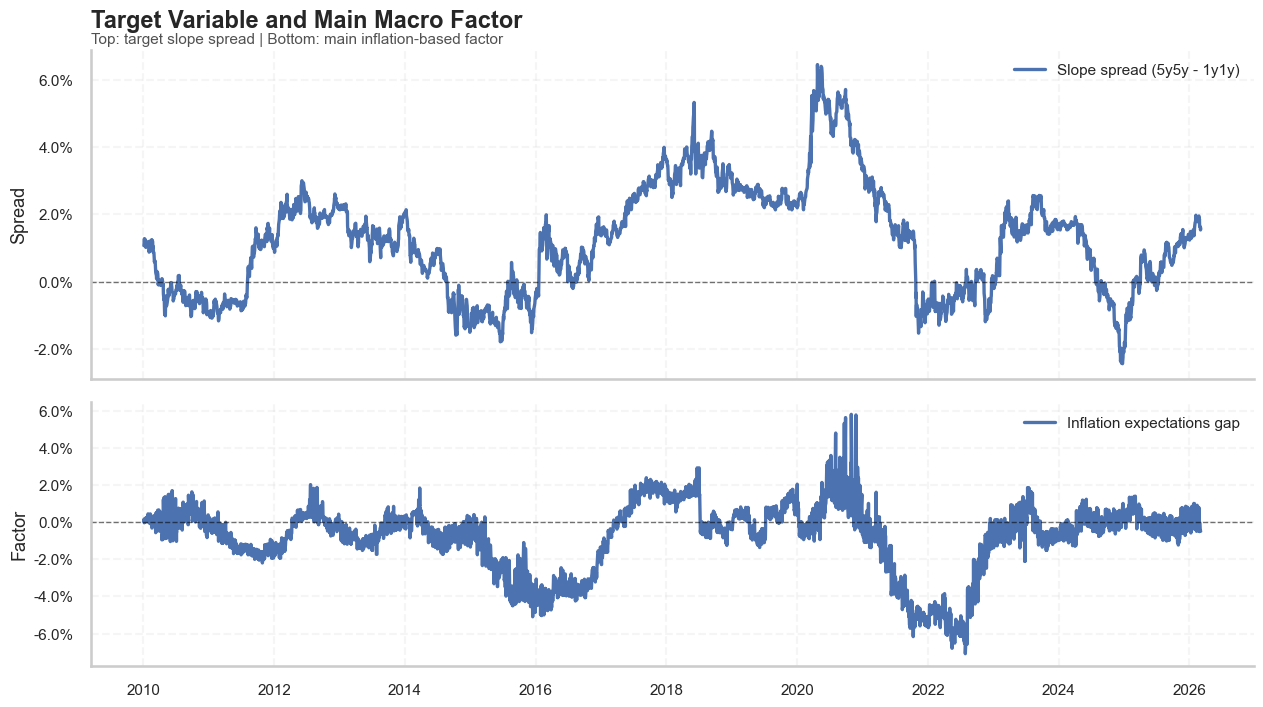

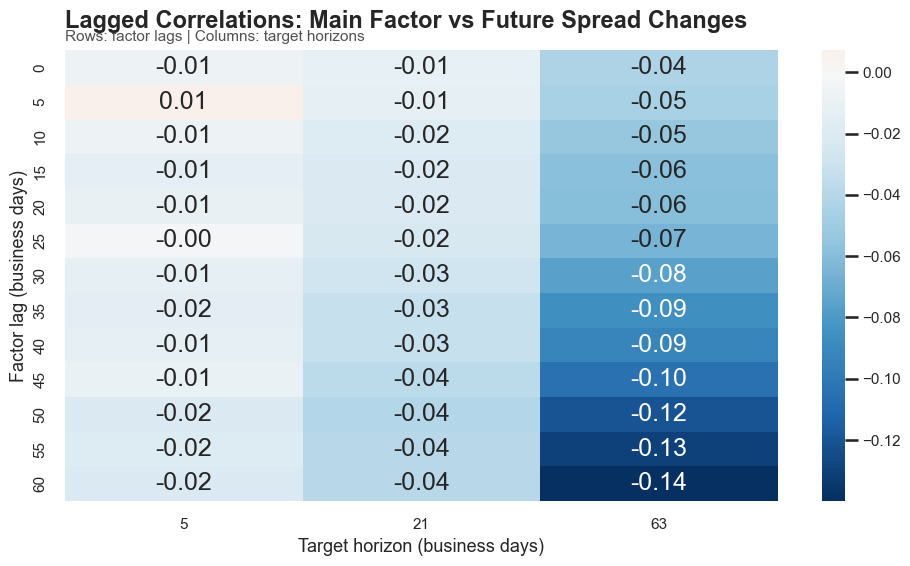


Predictive regressions:
                       factor                      factor_z  horizon_days  \
0  inflation_expectations_gap  inflation_expectations_gap_z             5   
1  inflation_expectations_gap  inflation_expectations_gap_z            21   
2  inflation_expectations_gap  inflation_expectations_gap_z            63   
3   inflation_persistence_gap   inflation_persistence_gap_z             5   
4   inflation_persistence_gap   inflation_persistence_gap_z            21   
5   inflation_persistence_gap   inflation_persistence_gap_z            63   

   nobs     alpha      beta  tstat_beta  pvalue_beta        r2  
0  4004  0.000521 -0.002218   -0.225347     0.821710  0.000060  
1  3988  0.003535 -0.006541   -0.174210     0.861700  0.000138  
2  3946  0.011635 -0.040071   -0.462628     0.643631  0.001871  
3  4004  0.000523  0.002664    0.281270     0.778504  0.000086  
4  3988  0.003588  0.013174    0.392109     0.694977  0.000560  
5  3946  0.012767  0.078094    1.124146     0

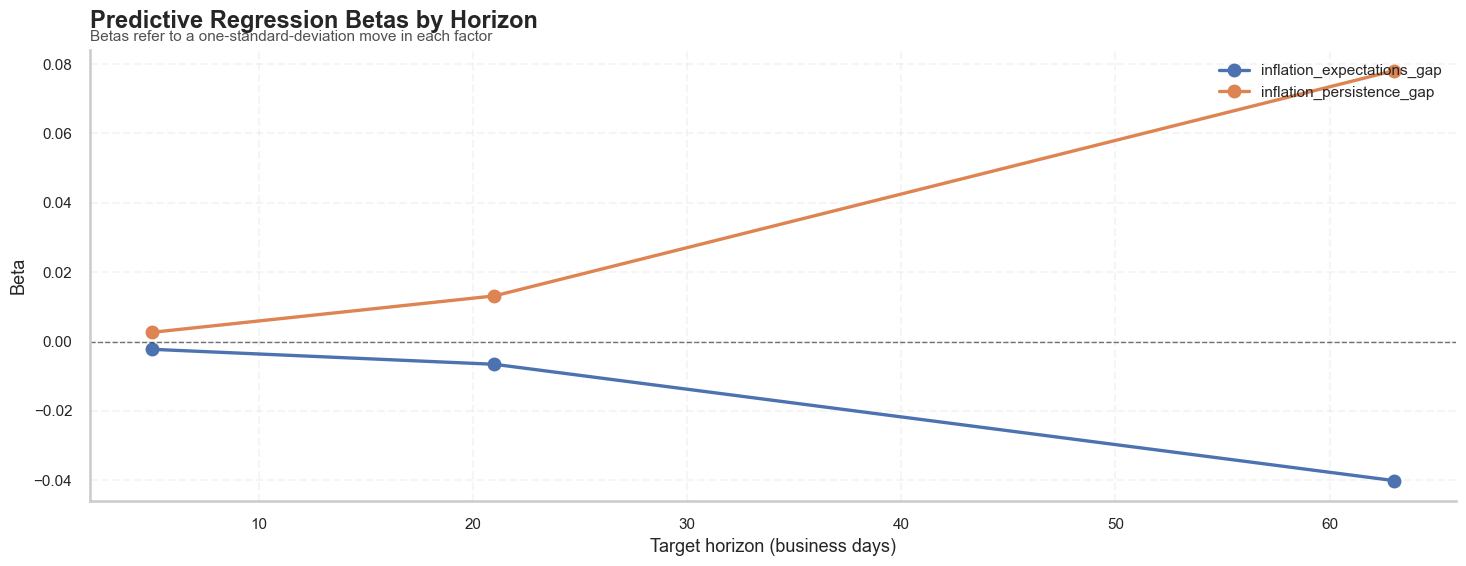


Granger causality results:
                       factor  lag_weeks  pvalue_x_causes_y
0  inflation_expectations_gap          1           0.404174
1  inflation_expectations_gap          2           0.483916
2  inflation_expectations_gap          3           0.605956
3  inflation_expectations_gap          4           0.656350
4   inflation_persistence_gap          1           0.488463
5   inflation_persistence_gap          2           0.790995
6   inflation_persistence_gap          3           0.484067
7   inflation_persistence_gap          4           0.183058


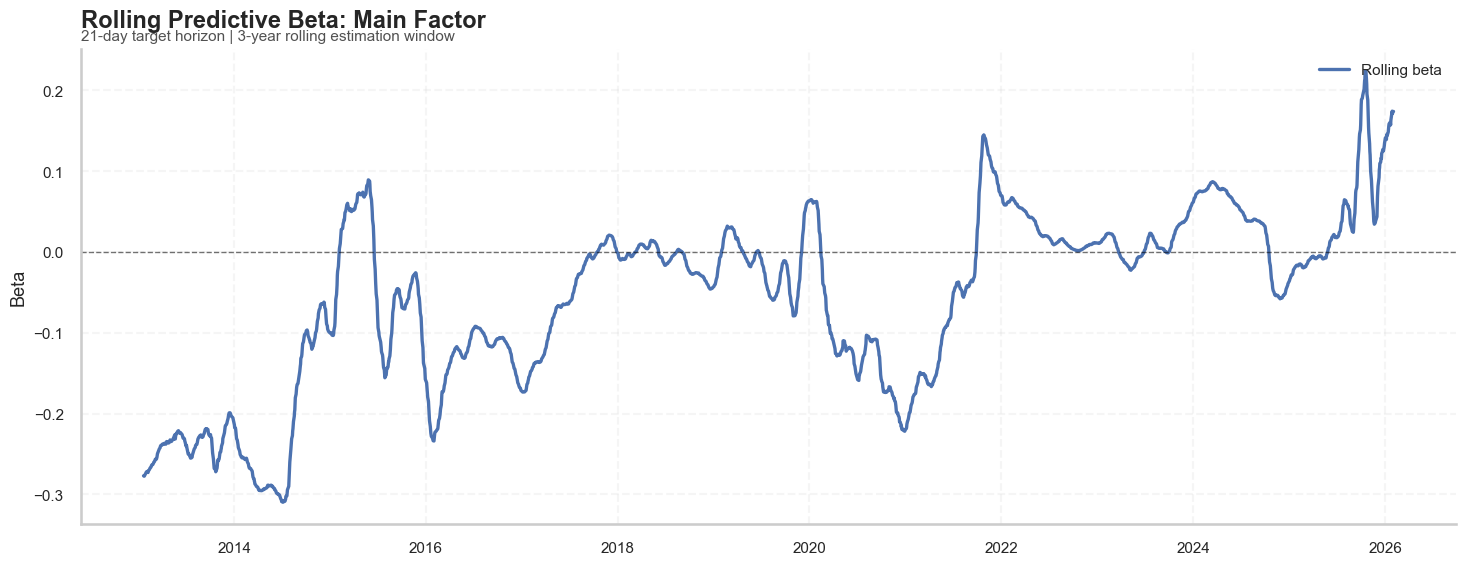

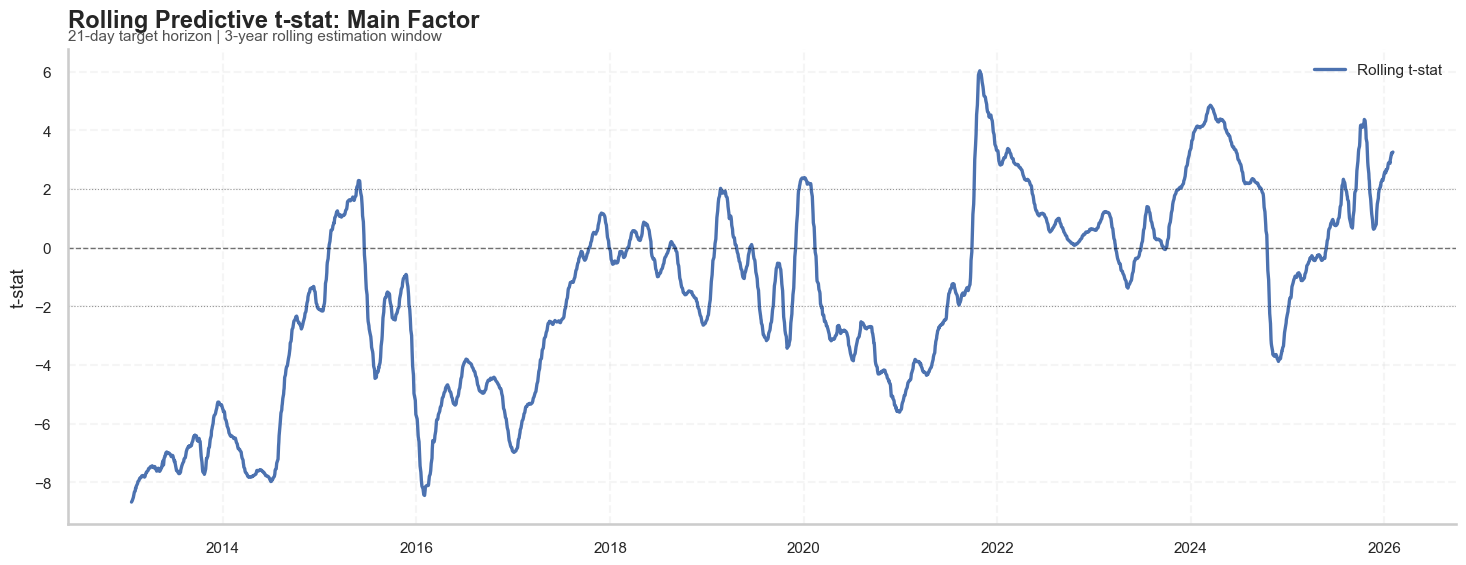


Main-factor summary table:
   horizon_days  nobs      beta  tstat_beta  pvalue_beta        r2
0             5  4004 -0.002218   -0.225347     0.821710  0.000060
1            21  3988 -0.006541   -0.174210     0.861700  0.000138
2            63  3946 -0.040071   -0.462628     0.643631  0.001871

Saved files:
- c:\Projetos\estudo_curva\data_processed\curve_macro_stat_ready.csv
- c:\Projetos\estudo_curva\data_processed\rolling_beta_main_factor.csv
- c:\Projetos\estudo_curva\tables\tab_01_stationarity_tests.csv
- c:\Projetos\estudo_curva\tables\tab_02_lagged_correlations.csv
- c:\Projetos\estudo_curva\tables\tab_03_predictive_regressions.csv
- c:\Projetos\estudo_curva\tables\tab_04_predictive_regressions_with_control.csv
- c:\Projetos\estudo_curva\tables\tab_05_granger_causality.csv
- c:\Projetos\estudo_curva\tables\tab_06_main_factor_report_summary.csv
- c:\Projetos\estudo_curva\figures\03_stat_tests\fig_06_target_and_main_factor.png
- c:\Projetos\estudo_curva\figures\03_stat_tests\fig_0

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests

# ------------------------------------------------------------
# 0) Paths and folders
# ------------------------------------------------------------
BASE_DIR = Path.cwd()

DATA_PROCESSED_DIR = BASE_DIR / "data_processed"
TABLES_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
STAT_FIG_DIR = FIG_DIR / "03_stat_tests"

DATA_PROCESSED_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
STAT_FIG_DIR.mkdir(exist_ok=True)

MERGED_CSV = DATA_PROCESSED_DIR / "curve_macro_merged.csv"

# ------------------------------------------------------------
# 1) Load merged dataset
# ------------------------------------------------------------
df = pd.read_csv(MERGED_CSV)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print("Merged dataset sample:")
print(df.head())
print(df.tail())
print(df.columns.tolist())

# ------------------------------------------------------------
# 2) Plot style
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (15, 6),
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "lines.linewidth": 2.4,
    "savefig.dpi": 300,
})

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def setup_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("")
    sns.despine(ax=ax)

def add_subtitle(ax, subtitle: str):
    ax.text(
        0.0,
        1.02,
        subtitle,
        transform=ax.transAxes,
        fontsize=11,
        alpha=0.80
    )

# ------------------------------------------------------------
# 3) Main variables
# ------------------------------------------------------------
TARGET_COL = "spread_5y5y_minus_1y1y"

MAIN_FACTOR = "inflation_expectations_gap"
ALT_FACTOR = "inflation_persistence_gap"

OPTIONAL_CONTROL = "ibc_br_sa_level"

required_cols = [TARGET_COL, MAIN_FACTOR, ALT_FACTOR]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in merged dataset: {missing_cols}")

# ------------------------------------------------------------
# 4) Build forward-looking targets
# ------------------------------------------------------------
# The target is the future change in the slope spread.
# Example:
#   spread_change_fwd_21d(t) = spread(t+21) - spread(t)
HORIZONS = [5, 21, 63]

for h in HORIZONS:
    df[f"spread_change_fwd_{h}d"] = df[TARGET_COL].shift(-h) - df[TARGET_COL]

# Standardized predictors for comparability in predictive regressions
# Full-sample z-scores are used only for statistical comparison here.
# The trading notebook will use rolling standardization out-of-sample.
for col in [MAIN_FACTOR, ALT_FACTOR]:
    mu = df[col].mean(skipna=True)
    sigma = df[col].std(skipna=True)
    df[f"{col}_z"] = (df[col] - mu) / sigma

# Daily first differences for stationarity and Granger tests
for col in [TARGET_COL, MAIN_FACTOR, ALT_FACTOR]:
    df[f"{col}_diff1"] = df[col].diff()

# Save an enriched version 
df.to_csv(DATA_PROCESSED_DIR / "curve_macro_stat_ready.csv", index=False)


def prettify_latex_value(x):
    return x

def save_table(
    df_table: pd.DataFrame,
    filename_stem: str,
    index: bool = False,
    rename_map: dict | None = None,
    value_maps: dict | None = None,
    float_fmt: str = "%.4f",
):
    """
    Save a table both as CSV and LaTeX, with LaTeX-safe headers/content.
    """
    out = df_table.copy()

    if value_maps:
        for col, mapper in value_maps.items():
            if col in out.columns:
                out[col] = out[col].replace(mapper)

    csv_path = TABLES_DIR / f"{filename_stem}.csv"
    out.to_csv(csv_path, index=index)


    out_tex = out.copy()

    if rename_map:
        out_tex = out_tex.rename(columns=rename_map)

    tex_path = TABLES_DIR / f"{filename_stem}.tex"

    latex_str = out_tex.to_latex(
        index=index,
        escape=True,
        float_format=float_fmt,
        na_rep=""
    )
    tex_path.write_text(latex_str, encoding="utf-8")


def save_latex_table(df: pd.DataFrame, path: str, rename_map=None, float_fmt="%.3f"):
    out = df.copy()

    if rename_map:
        out = out.rename(columns=rename_map)

    latex = out.to_latex(
        index=False,
        escape=True,
        float_format=float_fmt,
        na_rep=""
    )

    Path(path).write_text(latex, encoding="utf-8")


def run_adf(series: pd.Series):
    """
    Run ADF test and return summary statistics.
    """
    x = series.dropna()
    if len(x) < 50:
        return {"stat": np.nan, "pvalue": np.nan, "used_lags": np.nan, "nobs": len(x)}

    result = adfuller(x, autolag="AIC")
    return {
        "stat": result[0],
        "pvalue": result[1],
        "used_lags": result[2],
        "nobs": result[3],
    }

def run_kpss(series: pd.Series):
    """
    Run KPSS test and return summary statistics.
    """
    x = series.dropna()
    if len(x) < 50:
        return {"stat": np.nan, "pvalue": np.nan, "used_lags": np.nan, "nobs": len(x)}

    try:
        result = kpss(x, regression="c", nlags="auto")
        return {
            "stat": result[0],
            "pvalue": result[1],
            "used_lags": result[2],
            "nobs": len(x),
        }
    except Exception:
        return {"stat": np.nan, "pvalue": np.nan, "used_lags": np.nan, "nobs": len(x)}

stationarity_series = {
    "spread_level": df[TARGET_COL],
    "spread_diff1": df[f"{TARGET_COL}_diff1"],
    "main_factor_level": df[MAIN_FACTOR],
    "main_factor_diff1": df[f"{MAIN_FACTOR}_diff1"],
    "alt_factor_level": df[ALT_FACTOR],
    "alt_factor_diff1": df[f"{ALT_FACTOR}_diff1"],
}

stationarity_rows = []

for name, series in stationarity_series.items():
    adf_res = run_adf(series)
    kpss_res = run_kpss(series)

    stationarity_rows.append({
        "series": name,
        "adf_stat": adf_res["stat"],
        "adf_pvalue": adf_res["pvalue"],
        "kpss_stat": kpss_res["stat"],
        "kpss_pvalue": kpss_res["pvalue"],
        "nobs": adf_res["nobs"],
    })

stationarity_table = pd.DataFrame(stationarity_rows)
save_table(
    stationarity_table,
    "tab_01_stationarity_tests",
    index=False,
    rename_map={
        "series": "Series",
        "adf_stat": "ADF stat",
        "adf_pvalue": "ADF p-value",
        "kpss_stat": "KPSS stat",
        "kpss_pvalue": "KPSS p-value",
        "nobs": "Obs."
    }
)

print("\nStationarity tests:")
print(stationarity_table)

# ------------------------------------------------------------
# 7) Visual inspection of main series
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1.5, 1.2], "hspace": 0.08}
)

plot_df = df[["date", TARGET_COL, MAIN_FACTOR]].dropna().sort_values("date")

ax1.plot(plot_df["date"], plot_df[TARGET_COL], label="Slope spread (5y5y - 1y1y)")
ax1.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax1.set_title("Target Variable and Main Macro Factor", loc="left", pad=16, fontweight="bold")
add_subtitle(ax1, "Top: target slope spread | Bottom: main inflation-based factor")
ax1.set_ylabel("Spread")
ax1.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax1.legend(loc="upper right", frameon=False)

ax2.plot(plot_df["date"], plot_df[MAIN_FACTOR], label="Inflation expectations gap")
ax2.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax2.set_ylabel("Factor")
ax2.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax2.legend(loc="upper right", frameon=False)

setup_time_axis(ax2)

plt.tight_layout()
fig.savefig(STAT_FIG_DIR / "fig_06_target_and_main_factor.png", bbox_inches="tight")
fig.savefig(STAT_FIG_DIR / "fig_06_target_and_main_factor.pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 8) Lagged / predictive correlations
# ------------------------------------------------------------
# We compute correlations between factor(t - lag) and future spread changes.
# This helps visualize whether the factor leads the target.
MAX_LAG = 63
LAG_STEP = 5
lags = list(range(0, MAX_LAG + 1, LAG_STEP))

corr_rows = []

for factor in [MAIN_FACTOR, ALT_FACTOR]:
    for h in HORIZONS:
        target_col = f"spread_change_fwd_{h}d"

        for lag in lags:
            tmp = df[[factor, target_col]].copy()
            tmp["factor_lagged"] = tmp[factor].shift(lag)
            tmp = tmp[["factor_lagged", target_col]].dropna()

            corr_val = tmp["factor_lagged"].corr(tmp[target_col]) if len(tmp) > 30 else np.nan

            corr_rows.append({
                "factor": factor,
                "horizon_days": h,
                "lag_days": lag,
                "correlation": corr_val,
                "nobs": len(tmp),
            })

corr_table = pd.DataFrame(corr_rows)
save_table(
    corr_table,
    "tab_02_lagged_correlations",
    index=False,
    rename_map={
        "factor": "Factor",
        "horizon_days": "Horizon (days)",
        "lag_days": "Lag (days)",
        "correlation": "Correlation",
        "nobs": "Obs."
    },
    value_maps={
        "factor": {
            "inflation_expectations_gap": "Inflation expectations gap",
            "inflation_persistence_gap": "Inflation persistence gap"
        }
    }
)

# Heatmap for main factor
heatmap_main = corr_table[corr_table["factor"] == MAIN_FACTOR].pivot(
    index="lag_days",
    columns="horizon_days",
    values="correlation"
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_main,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0.0,
    ax=ax
)
ax.set_title("Lagged Correlations: Main Factor vs Future Spread Changes", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Rows: factor lags | Columns: target horizons")
ax.set_xlabel("Target horizon (business days)")
ax.set_ylabel("Factor lag (business days)")

plt.tight_layout()
fig.savefig(STAT_FIG_DIR / "fig_07_lagged_correlation_heatmap_main.png", bbox_inches="tight")
fig.savefig(STAT_FIG_DIR / "fig_07_lagged_correlation_heatmap_main.pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 9) Predictive regressions
# ------------------------------------------------------------
# Univariate predictive regressions:
#   future spread change(h) = alpha + beta * factor_z + error
#
# HAC/Newey-West standard errors are used because:
# - targets are overlapping for h > 1
# - macro predictors are persistent
def predictive_regression(data: pd.DataFrame, y_col: str, x_col: str, hac_lags: int):
    """
    Run OLS with HAC standard errors and return a compact summary.
    """
    tmp = data[[y_col, x_col]].dropna().copy()

    if len(tmp) < 80:
        return {
            "nobs": len(tmp),
            "alpha": np.nan,
            "beta": np.nan,
            "tstat_beta": np.nan,
            "pvalue_beta": np.nan,
            "r2": np.nan,
        }

    X = sm.add_constant(tmp[[x_col]])
    y = tmp[y_col]

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

    return {
        "nobs": int(model.nobs),
        "alpha": model.params.get("const", np.nan),
        "beta": model.params.get(x_col, np.nan),
        "tstat_beta": model.tvalues.get(x_col, np.nan),
        "pvalue_beta": model.pvalues.get(x_col, np.nan),
        "r2": model.rsquared,
    }

regression_rows = []

for factor, factor_z in [
    (MAIN_FACTOR, f"{MAIN_FACTOR}_z"),
    (ALT_FACTOR, f"{ALT_FACTOR}_z"),
]:
    for h in HORIZONS:
        y_col = f"spread_change_fwd_{h}d"
        res = predictive_regression(df, y_col, factor_z, hac_lags=h)

        regression_rows.append({
            "factor": factor,
            "factor_z": factor_z,
            "horizon_days": h,
            **res
        })

regression_table = pd.DataFrame(regression_rows)
save_table(
    regression_table,
    "tab_03_predictive_regressions",
    index=False,
    rename_map={
        "factor": "Factor",
        "factor_z": "Standardized factor",
        "horizon_days": "Horizon (days)",
        "nobs": "Obs.",
        "alpha": "Alpha",
        "beta": "Beta",
        "tstat_beta": "t-stat",
        "pvalue_beta": "p-value",
        "r2": "R-squared"
    },
    value_maps={
        "factor": {
            "inflation_expectations_gap": "Inflation expectations gap",
            "inflation_persistence_gap": "Inflation persistence gap"
        },
        "factor_z": {
            "inflation_expectations_gap_z": "Inflation expectations gap (z)",
            "inflation_persistence_gap_z": "Inflation persistence gap (z)"
        }
    }
)

print("\nPredictive regressions:")
print(regression_table)

# Plot beta by horizon
plot_reg = regression_table.copy()

fig, ax = plt.subplots()

for factor_name in [MAIN_FACTOR, ALT_FACTOR]:
    tmp = plot_reg[plot_reg["factor"] == factor_name].sort_values("horizon_days")
    ax.plot(
        tmp["horizon_days"],
        tmp["beta"],
        marker="o",
        label=factor_name
    )

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.set_title("Predictive Regression Betas by Horizon", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Betas refer to a one-standard-deviation move in each factor")
ax.set_xlabel("Target horizon (business days)")
ax.set_ylabel("Beta")
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(STAT_FIG_DIR / "fig_08_predictive_betas_by_horizon.png", bbox_inches="tight")
fig.savefig(STAT_FIG_DIR / "fig_08_predictive_betas_by_horizon.pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 10) Optional multivariate robustness regression
# ------------------------------------------------------------
# This is kept simple and only adds one control variable.
# The report can still focus on the univariate specification.
multivar_rows = []

if OPTIONAL_CONTROL in df.columns:
    control_mu = df[OPTIONAL_CONTROL].mean(skipna=True)
    control_sigma = df[OPTIONAL_CONTROL].std(skipna=True)
    df[f"{OPTIONAL_CONTROL}_z"] = (df[OPTIONAL_CONTROL] - control_mu) / control_sigma

    for h in HORIZONS:
        y_col = f"spread_change_fwd_{h}d"
        x_cols = [f"{MAIN_FACTOR}_z", f"{OPTIONAL_CONTROL}_z"]

        tmp = df[[y_col] + x_cols].dropna().copy()

        if len(tmp) < 80:
            multivar_rows.append({
                "horizon_days": h,
                "nobs": len(tmp),
                "beta_main": np.nan,
                "tstat_main": np.nan,
                "beta_control": np.nan,
                "tstat_control": np.nan,
                "r2": np.nan,
            })
            continue

        X = sm.add_constant(tmp[x_cols])
        y = tmp[y_col]

        model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": h})

        multivar_rows.append({
            "horizon_days": h,
            "nobs": int(model.nobs),
            "beta_main": model.params.get(f"{MAIN_FACTOR}_z", np.nan),
            "tstat_main": model.tvalues.get(f"{MAIN_FACTOR}_z", np.nan),
            "beta_control": model.params.get(f"{OPTIONAL_CONTROL}_z", np.nan),
            "tstat_control": model.tvalues.get(f"{OPTIONAL_CONTROL}_z", np.nan),
            "r2": model.rsquared,
        })

multivar_table = pd.DataFrame(multivar_rows)
save_table(
    multivar_table,
    "tab_04_predictive_regressions_with_control",
    index=False,
    rename_map={
        "horizon_days": "Horizon (days)",
        "nobs": "Obs.",
        "beta_main": "Beta (main factor)",
        "tstat_main": "t-stat (main factor)",
        "beta_control": "Beta (control)",
        "tstat_control": "t-stat (control)",
        "r2": "R-squared"
    }
)

# ------------------------------------------------------------
# 11) Granger causality
# ------------------------------------------------------------
# Granger tests are more meaningful on stationary transformations.
# To reduce noise and avoid too many repeated values, we resample to weekly frequency.
weekly = df.set_index("date")[[TARGET_COL, MAIN_FACTOR, ALT_FACTOR]].resample("W-FRI").last().dropna().copy()

weekly[f"{TARGET_COL}_diff1"] = weekly[TARGET_COL].diff()
weekly[f"{MAIN_FACTOR}_diff1"] = weekly[MAIN_FACTOR].diff()
weekly[f"{ALT_FACTOR}_diff1"] = weekly[ALT_FACTOR].diff()

weekly_gc = weekly.dropna().copy()

def granger_pvalues(data: pd.DataFrame, x_col: str, y_col: str, maxlag: int = 4):
    """
    Test whether x Granger-causes y.
    Returns p-values for the SSR F-test across lags.
    """
    tmp = data[[y_col, x_col]].dropna().copy()

    if len(tmp) < 60:
        return {lag: np.nan for lag in range(1, maxlag + 1)}

    results = grangercausalitytests(tmp[[y_col, x_col]], maxlag=maxlag, verbose=False)
    out = {}

    for lag in range(1, maxlag + 1):
        out[lag] = results[lag][0]["ssr_ftest"][1]

    return out

granger_rows = []

for factor in [MAIN_FACTOR, ALT_FACTOR]:
    pvals = granger_pvalues(
        weekly_gc,
        x_col=f"{factor}_diff1",
        y_col=f"{TARGET_COL}_diff1",
        maxlag=4
    )

    for lag, pval in pvals.items():
        granger_rows.append({
            "factor": factor,
            "lag_weeks": lag,
            "pvalue_x_causes_y": pval
        })

granger_table = pd.DataFrame(granger_rows)
save_table(
    granger_table,
    "tab_05_granger_causality",
    index=False,
    rename_map={
        "factor": "Factor",
        "lag_weeks": "Lag (weeks)",
        "pvalue_x_causes_y": "p-value"
    },
    value_maps={
        "factor": {
            "inflation_expectations_gap": "Inflation expectations gap",
            "inflation_persistence_gap": "Inflation persistence gap"
        }
    }
)

print("\nGranger causality results:")
print(granger_table)

# ------------------------------------------------------------
# 12) Rolling beta stability
# ------------------------------------------------------------
# We estimate rolling OLS betas for the 21-day predictive regression:
#   spread_change_fwd_21d = alpha + beta * main_factor_z + error
#
# This is a stability diagnostic, not the final trading backtest.
ROLLING_WINDOW = 756  # approximately 3 business years
ROLLING_HORIZON = 21

roll_target = f"spread_change_fwd_{ROLLING_HORIZON}d"
roll_factor = f"{MAIN_FACTOR}_z"

rolling_rows = []

tmp_roll = df[["date", roll_target, roll_factor]].dropna().copy().reset_index(drop=True)

for end_ix in range(ROLLING_WINDOW, len(tmp_roll) + 1):
    window_df = tmp_roll.iloc[end_ix - ROLLING_WINDOW:end_ix].copy()

    X = sm.add_constant(window_df[[roll_factor]])
    y = window_df[roll_target]

    try:
        model = sm.OLS(y, X).fit()
        rolling_rows.append({
            "date": window_df["date"].iloc[-1],
            "beta": model.params.get(roll_factor, np.nan),
            "tstat": model.tvalues.get(roll_factor, np.nan),
            "r2": model.rsquared,
        })
    except Exception:
        rolling_rows.append({
            "date": window_df["date"].iloc[-1],
            "beta": np.nan,
            "tstat": np.nan,
            "r2": np.nan,
        })

rolling_beta_df = pd.DataFrame(rolling_rows)
rolling_beta_df.to_csv(DATA_PROCESSED_DIR / "rolling_beta_main_factor.csv", index=False)

# Plot rolling beta
fig, ax = plt.subplots()

ax.plot(
    rolling_beta_df["date"],
    rolling_beta_df["beta"],
    label="Rolling beta"
)

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)

ax.set_title("Rolling Predictive Beta: Main Factor", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "21-day target horizon | 3-year rolling estimation window")

ax.set_ylabel("Beta")
setup_time_axis(ax)

ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(STAT_FIG_DIR / "fig_09_rolling_beta_main_factor.png", bbox_inches="tight")
fig.savefig(STAT_FIG_DIR / "fig_09_rolling_beta_main_factor.pdf", bbox_inches="tight")
plt.show()

# Plot rolling t-stat
fig, ax = plt.subplots()

ax.plot(
    rolling_beta_df["date"],
    rolling_beta_df["tstat"],
    label="Rolling t-stat"
)

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.axhline(2.0, color="black", linewidth=0.8, linestyle=":", alpha=0.40)
ax.axhline(-2.0, color="black", linewidth=0.8, linestyle=":", alpha=0.40)

ax.set_title("Rolling Predictive t-stat: Main Factor", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "21-day target horizon | 3-year rolling estimation window")

ax.set_ylabel("t-stat")
setup_time_axis(ax)

ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(STAT_FIG_DIR / "fig_10_rolling_tstat_main_factor.png", bbox_inches="tight")
fig.savefig(STAT_FIG_DIR / "fig_10_rolling_tstat_main_factor.pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 13) Summary table for the main report
# ------------------------------------------------------------
# A compact table that can go directly into the report body.
report_table = regression_table[regression_table["factor"] == MAIN_FACTOR].copy()
report_table = report_table[[
    "horizon_days",
    "nobs",
    "beta",
    "tstat_beta",
    "pvalue_beta",
    "r2",
]].sort_values("horizon_days").reset_index(drop=True)

save_table(
    report_table,
    "tab_06_main_factor_report_summary",
    index=False,
    rename_map={
        "horizon_days": "Horizon (days)",
        "nobs": "Obs.",
        "beta": "Beta",
        "tstat_beta": "t-stat",
        "pvalue_beta": "p-value",
        "r2": "R-squared"
    }
)

print("\nMain-factor summary table:")
print(report_table)

print("\nSaved files:")
print(f"- {DATA_PROCESSED_DIR / 'curve_macro_stat_ready.csv'}")
print(f"- {DATA_PROCESSED_DIR / 'rolling_beta_main_factor.csv'}")
print(f"- {TABLES_DIR / 'tab_01_stationarity_tests.csv'}")
print(f"- {TABLES_DIR / 'tab_02_lagged_correlations.csv'}")
print(f"- {TABLES_DIR / 'tab_03_predictive_regressions.csv'}")
print(f"- {TABLES_DIR / 'tab_04_predictive_regressions_with_control.csv'}")
print(f"- {TABLES_DIR / 'tab_05_granger_causality.csv'}")
print(f"- {TABLES_DIR / 'tab_06_main_factor_report_summary.csv'}")
print(f"- {STAT_FIG_DIR / 'fig_06_target_and_main_factor.png'}")
print(f"- {STAT_FIG_DIR / 'fig_07_lagged_correlation_heatmap_main.png'}")
print(f"- {STAT_FIG_DIR / 'fig_08_predictive_betas_by_horizon.png'}")
print(f"- {STAT_FIG_DIR / 'fig_09_rolling_beta_main_factor.png'}")
print(f"- {STAT_FIG_DIR / 'fig_10_rolling_tstat_main_factor.png'}")

In [12]:
fair_rows = []

fair_specs = [
    {
        "spec_label": "Main factor only",
        "x_cols": [f"{MAIN_FACTOR}_z"]
    }
]

if f"{OPTIONAL_CONTROL}_z" in df.columns:
    fair_specs.append({
        "spec_label": "Main factor + activity control",
        "x_cols": [f"{MAIN_FACTOR}_z", f"{OPTIONAL_CONTROL}_z"]
    })

for spec in fair_specs:
    x_cols = spec["x_cols"]
    tmp = df[[TARGET_COL] + x_cols].dropna().copy()

    if len(tmp) < 80:
        fair_rows.append({
            "spec": spec["spec_label"],
            "nobs": len(tmp),
            "r2": np.nan,
            "beta_main": np.nan,
            "tstat_main": np.nan,
            "beta_control": np.nan,
            "tstat_control": np.nan,
        })
        continue

    X = sm.add_constant(tmp[x_cols])
    y = tmp[TARGET_COL]

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 21})

    fair_rows.append({
        "spec": spec["spec_label"],
        "nobs": int(model.nobs),
        "r2": model.rsquared,
        "beta_main": model.params.get(f"{MAIN_FACTOR}_z", np.nan),
        "tstat_main": model.tvalues.get(f"{MAIN_FACTOR}_z", np.nan),
        "beta_control": model.params.get(f"{OPTIONAL_CONTROL}_z", np.nan),
        "tstat_control": model.tvalues.get(f"{OPTIONAL_CONTROL}_z", np.nan),
    })

fair_table = pd.DataFrame(fair_rows)

save_table(
    fair_table,
    "tab_06_fair_value_level_regressions",
    index=False,
    rename_map={
        "spec": "Specification",
        "nobs": "Obs.",
        "r2": "R-squared",
        "beta_main": "Beta (main factor)",
        "tstat_main": "t-stat (main factor)",
        "beta_control": "Beta (control)",
        "tstat_control": "t-stat (control)",
    }
)